In [5]:
# ================================

# Brain Tumor Detection using CNN (Colab + Google Drive)

# ================================

# 1. Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# 2. Set Dataset Path (CHANGE if needed)

DATASET_PATH = "/content/drive/MyDrive/brain_tumor_dataset"

In [7]:
# 3. Import Libraries

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.keras import layers, models


In [8]:

# 4. Load Dataset

dataset = tf.keras.preprocessing.image_dataset_from_directory(
DATASET_PATH,
image_size=(224,224),
batch_size=32
)

Found 506 files belonging to 2 classes.


In [9]:

# 5. Check Classes (AUTO FIX)

print("Classes:", dataset.class_names)
num_classes = len(dataset.class_names)


Classes: ['test', 'train']


In [10]:
# 6. Normalize Data

dataset = dataset.map(lambda x, y: (x/255.0, y))

# 7. Split Dataset

train_size = int(0.8 * len(dataset))
train_dataset = dataset.take(train_size)
test_dataset = dataset.skip(train_size)

In [11]:
# 8. Build CNN Model

model = models.Sequential([
layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
layers.MaxPooling2D((2,2)),


layers.Conv2D(64,(3,3),activation='relu'),
layers.MaxPooling2D((2,2)),

layers.Conv2D(128,(3,3),activation='relu'),
layers.MaxPooling2D((2,2)),

layers.Flatten(),
layers.Dense(128,activation='relu'),

# AUTO FIXED OUTPUT LAYER
layers.Dense(num_classes, activation='softmax')


])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
# 9. Compile Model

model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)

# 10. Train Model

history = model.fit(train_dataset, epochs=8)


Epoch 1/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step - accuracy: 0.5234 - loss: 0.6943
Epoch 2/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step - accuracy: 0.4870 - loss: 0.6989
Epoch 3/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - accuracy: 0.4974 - loss: 0.6931
Epoch 4/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.4948 - loss: 0.6932
Epoch 5/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - accuracy: 0.5156 - loss: 0.6932
Epoch 6/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.5156 - loss: 0.6930
Epoch 7/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.4974 - loss: 0.6933
Epoch 8/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.5026 - loss: 0.6932


4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.5656 - loss: 0.6917


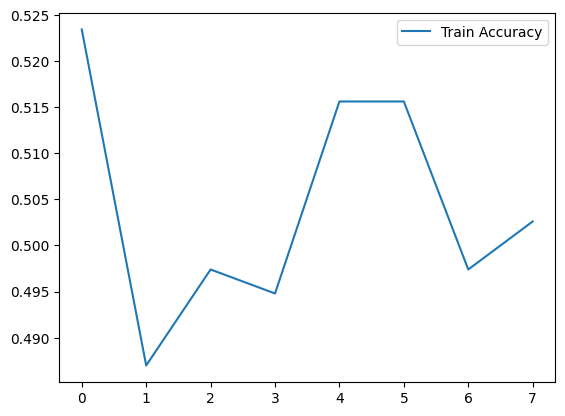

In [15]:
# 11. Evaluate Model

model.evaluate(test_dataset)

# 12. Plot Accuracy

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.legend()
plt.show()